# 四节点单台区：通过对偶切割恢复负荷倍率—建设预算可规划域

**研究边界：**所有道路已知可建设；不含勘察、阻断和负荷鲁棒性。节点负荷保持空间比例，统一乘以 $\lambda$。建设方案含离散网架和离散线型。

这是教学用**合成模型**，不是江口数据。采用无损有功平衡和线性平方电压，未作 AC 复核。将本 Notebook 与两个 `.py` 文件放在同一目录中运行。

核心问题：只在二维平面加半空间割，是否足够？保留整数主变量后，对偶割能否恢复真正的非凸阶梯边界？

所有优化模型均用 `gurobipy` 建模与求解。选择 **Python (PlanRegion - Gurobi)** 内核后运行全部单元；输出保存至 `notebook_results`。

In [1]:
from pathlib import Path
import gurobipy as gp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from planning_domain_demo import (
    DemoConfig, build_model, enumerate_designs, frontier_table,
    solve_by_cuts, discover_frontier_by_cuts, validate_cuts, run_experiment,
)
from plot_demo import plot_network, plot_frontier, plot_convergence, plot_cut_snapshots

OUTPUT = Path("notebook_results")
OUTPUT.mkdir(exist_ok=True)
config = DemoConfig()  # 修改算例参数后，从头运行 notebook。
model = build_model(config)
print("Gurobi:", ".".join(map(str, gp.gurobi.version())))
display(pd.DataFrame([vars(e) for e in model.corridors]))
display(pd.DataFrame([vars(t) for t in model.lines]))
print("基准负荷 (kW):", config.loads_kw, "；配变限制倍率:", model.transformer_limit)

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2685996


Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


Gurobi: 13.0.2


,name,start,end,length_m,existing
0,01,0,1,220.0,True
1,12,1,2,180.0,True
2,13,1,3,240.0,True
3,02,0,2,300.0,False
4,23,2,3,160.0,False


,name,r_ohm_km,x_ohm_km,capacity_kw,cable_cny_m
0,L,1.15,0.08,35.0,28.0
1,M,0.62,0.08,65.0,43.0
2,H,0.32,0.08,100.0,65.0


基准负荷 (kW): (0.0, 25.0, 20.0, 15.0) ；配变限制倍率: 2.375


## 当前网络节点示意图

**图 1 | 四节点台区及候选建设走廊。** 方形节点 0 为根节点和 150 kVA 配变，圆形节点 1、2、3 的基准负荷分别为 25、20、15 kW；实际负荷为基准值乘统一倍率 λ。实线为现有 L 型线路 0–1、1–2、1–3，虚线为可选新建走廊 0–2、2–3。标注数值为线路长度。节点坐标仅用于表达拓扑，不代表地理位置，几何距离不按线路长度缩放。最终建设方案从这些走廊中选取三条边组成生成树。

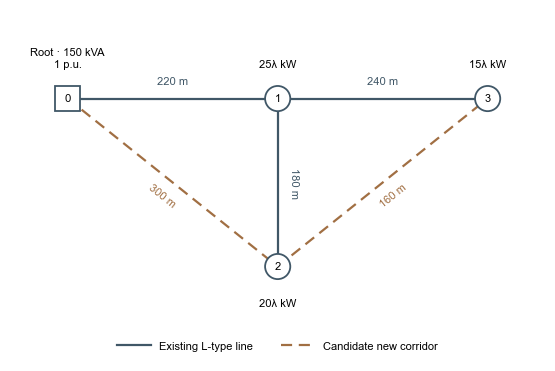

In [2]:
fig = plot_network(model, OUTPUT / "figures")
plt.show()

## 1. 单台区电气与离散建设模型

根0连接3个负荷点，基准有功分别为25、20、15 kW。现有边01、12、13，可选新边02、23。
最终闭合线路必须组成一棵生成树；每条选中边选择L/M/H之一。已有L型保留成本为0，换线按新电缆全长计费，新道路另加施工费。

固定功率因数 $\tan\varphi=\sqrt{1-\mathrm{PF}^2}/\mathrm{PF}$，选中型号 $k$ 的线路满足
$$v_j-v_i+\frac{2(R_{ek}+X_{ek}\tan\varphi)}{1000V_{LL}^2}P_e=0,$$
其中 $P_e$ 以 kW、$R,X$ 以该线段的 ohm、$V_{LL}$ 以 kV 计。

节点平衡的需求为 $\lambda p_i^0$，线容量、配变容量、电压边界都不松弛。子问题中的人工松弛只用于诊断与产生割。

固定树后，下游负荷确定 $P_e(\lambda)=\lambda\sum_{i\in\mathrm{Desc}(e)}p_i^0$，因而可以独立解析得到每个方案的最大倍率。

In [3]:
designs = enumerate_designs(model)
frontier = frontier_table(designs)
print("完整整数方案数量:", len(designs))
print("MILP 主问题的线型二元变量:", model.nx)
print("连续子问题状态数量:", model.W.shape[1])
display(frontier)

完整整数方案数量: 216
MILP 主问题的线型二元变量: 15
连续子问题状态数量: 8


,cost_cny,lambda_max,bottleneck,design
0,0.0,0.546915,voltage:2,01:L; 12:L; 13:L
1,9460.0,0.846640,voltage:2,01:M; 12:L; 13:L
2,14300.0,1.227380,voltage:2,01:H; 12:L; 13:L
3,32360.0,1.566887,voltage:2,01:H; 12:M; 13:M
4,41600.0,1.666667,capacity:01,01:H; 12:H; 13:H
5,51020.0,2.011144,voltage:3,01:H; 13:M; 02:M
6,56300.0,2.375000,transformer,01:H; 13:H; 02:M


## 2. 不把整个MILP对偶化：只对连续电气检查器取对偶

统一电气模型为 $Ww\le h+Tx+d\lambda$。

给定整数 $\bar x$ 与倍率 $\bar\lambda$，检查
$$\nu=\min_{w,\eta\ge0}\eta\quad\text{s.t.}\quad Ww\le h+T\bar x+d\bar\lambda+r\eta.$$

对偶集合 $\Pi=\{\pi\ge0:W^T\pi=0,r^T\pi\le1\}$ 与建设方案和倍率无关。
若 $\nu>0$，由真实 LP 对偶解产生
$$\pi^T(h+Tx+d\lambda)\ge0.$$

**割加入含15个二元变量的主问题，不是直接当作二维域的半空间。** 固定预算时主问题最大化倍率，其松弛值是最大倍率的上界；当前完整方案实际可供倍率提供下界。

### Gurobi 对应写法

- `build_model`：用 `addVars`、`addConstr` 逐项写出容量、功率平衡、平方电压和压降约束；目标为 `setObjective(eta, GRB.MINIMIZE)`。
- `build_master`：定义二元变量 `x[e, k]` 和倍率变量；通过 `addConstrs` 写线型选择和生成树约束，按查询方向最小化费用或最大化倍率。迭代时向同一个主问题加入新割。
- `feasibility_oracle`：固定设计和倍率后更新电气 LP 的 `RHS`，调用 `optimize()`，读取约束的 `Pi`。最小化问题中，`<=` 约束的 `Pi` 非正，因此理论中的乘子取 `pi = -Pi`。

代码中的 $W,h,T,d$ 从上述 Gurobi 约束自动提取，只用于参数化 RHS 和构造对偶证书；无需手工拼接求解器矩阵。子问题最终仅保留 5 个潮流、3 个平方电压及 1 个违反量变量。

In [4]:
cold_cuts = []
cold = solve_by_cuts(model, "max_lambda", 33000.0, cold_cuts)
print("结果:", cold.status, "最大倍率:", cold.value)
print("新增对偶割:", cold.new_cuts)
display(cold.trace[["iteration", "master_candidate_lambda", "violation", "lower_bound", "upper_bound", "design"]])

结果: optimal 最大倍率: 1.5668874267432242
新增对偶割: 10


,iteration,master_candidate_lambda,violation,lower_bound,upper_bound,design
0,0,3.000000,0.625000,0.546915,3.000000,01:L; 12:L; 13:L
1,1,2.375000,0.358333,0.546915,2.375000,01:L; 12:L; 13:L
2,2,2.250000,0.183333,0.740982,2.250000,01:L; 13:L; 02:H
3,3,1.666667,0.053365,1.227380,1.666667,01:H; 12:L; 13:L
4,4,1.666667,0.112091,1.227380,1.666667,01:H; 13:L; 23:H
5,5,1.666667,0.043551,1.227380,1.666667,01:H; 12:L; 13:M
6,6,1.666667,0.045732,1.227380,1.666667,01:H; 12:H; 13:L
7,7,1.666667,0.010981,1.566887,1.666667,01:H; 12:M; 13:M
8,8,1.666667,0.090240,1.566887,1.666667,01:H; 12:L; 23:H
9,9,1.625000,0.055481,1.566887,1.625000,01:M; 13:L; 02:L


## 3. 不用倍率网格，恢复全部有效台阶

以所有费用的精确最大公约数 $\delta_C=20$ CNY 为单位，从足够大的预算开始：

1. 固定预算，用整数主问题＋对偶割最大化 $\lambda$。
2. 固定得到的倍率，用同一类算法最小化建设费 $C$。
3. 记录 $(\lambda,C)$，下一预算设为 $C-\delta_C$，重复至无更便宜方案。

所有方案费用是有限且离散的；这个预算递推不会漏掉费用严格更低、能力也更低的下一台阶。前面的穷举只作事后独立验证，不向本循环提供待查询的边界点。

In [5]:
recovery_cuts = cold_cuts.copy()
recovered = discover_frontier_by_cuts(model, recovery_cuts)
assert np.allclose(recovered.cost_cny, frontier.cost_cny, atol=1e-6, rtol=0)
assert np.allclose(recovered.lambda_max, frontier.lambda_max, atol=2e-6, rtol=0)
margin = validate_cuts(recovery_cuts, designs)
print("全部有效台阶已由切割算法独立恢复；最小割有效性余量:", margin)
display(recovered)

全部有效台阶已由切割算法独立恢复；最小割有效性余量: -1.942890293094024e-16


,cost_cny,lambda_max,bottleneck,design,search_budget_cny,master_solves
0,0.0,0.546915,voltage:2,01:L; 12:L; 13:L,9440.0,3
1,9460.0,0.846640,voltage:2,01:M; 12:L; 13:L,14280.0,3
2,14300.0,1.227380,voltage:2,01:H; 12:L; 13:L,32340.0,2
3,32360.0,1.566887,voltage:2,01:H; 12:M; 13:M,41580.0,4
4,41600.0,1.666667,capacity:01,01:H; 12:H; 13:H,51000.0,16
5,51020.0,2.011144,voltage:3,01:H; 13:M; 02:M,56280.0,7
6,56300.0,2.375000,transformer,01:H; 13:H; 02:M,193780.0,6


## 4. 系统交叉检查

以下运行包含：全部216个方案的最大倍率LP检查及超限检查；8个固定倍率费用查询；7个固定预算能力查询；完整前沿恢复；全部对偶割在216个方案的整个可行倍率区间上的有效性校验。

这些断言验证的是本例的线性模型，不是AC实际网络。完整输入、割系数和结果写入 `notebook_results`。

In [6]:
experiment = run_experiment(OUTPUT, config, model.lines, model.corridors)
display(experiment["validation"])
print("核验摘要:")
for key, value in experiment["summary"].items():
    print(f"{key}: {value}")

,mode,query,value,enumeration_value,status,new_cuts,master_solves
0,min_cost,0.4,0.000000e+00,0.000000e+00,optimal,0,1
1,min_cost,0.7,9.460000e+03,9.460000e+03,optimal,0,1
2,min_cost,1.0,1.430000e+04,1.430000e+04,optimal,1,2
3,min_cost,1.3,3.236000e+04,3.236000e+04,optimal,0,1
4,min_cost,1.6,4.160000e+04,4.160000e+04,optimal,15,16
5,min_cost,1.8,5.102000e+04,5.102000e+04,optimal,5,6
6,min_cost,2.1,5.630000e+04,5.630000e+04,optimal,4,5
7,min_cost,2.4,inf,inf,infeasible,0,0
8,max_lambda,0.0,5.469151e-01,5.469151e-01,optimal,1,2
9,max_lambda,10000.0,8.466403e-01,8.466403e-01,optimal,0,1


核验摘要:
solver: Gurobi
gurobi_version: 13.0.2
synthetic_case_not_jiangkou: True
nodes: 4
load_nodes: 3
candidate_corridors: 5
binary_line_choice_variables: 15
spanning_trees: 8
enumerated_designs: 216
frontier_steps: 7
frontier_recovered_without_lambda_grid: True
frontier_discovery_master_solves: 18
validation_queries: 15
lp_checks_of_design_endpoints: 432
total_cuts: 40
worst_cut_margin: -1.942890293094024e-16
cold_budget_cny: 33000.0
cold_master_solves: 11
cold_generated_cuts: 10
cold_lambda_max: 1.5668874267432222
nonconvex_counterexample_lambda: 1.1
exact_cost_at_counterexample: 14300.0
convex_hull_lower_cost_at_counterexample: 11623.109918602398
ac_power_flow_validated: False
electrical_model: lossless fixed-PF linear squared-voltage model


## 5. 非凸阶梯与凸包的区别

每个完整设计对应 $[0,\lambda_{\max}(x)]\times[C(x),\infty)$，全部设计取并集。
当 $\lambda=1.1$，本例真实最低费用14,300 CNY；完整二维凸包下边界却约11,623.11 CNY。凸包中的这个点不能由任何单一建设方案实现。

因此，只加二维全局有效线性割，无法消除所有这样的虚假点。下面的叉号是整数主问题＋对偶割独立恢复的前沿。

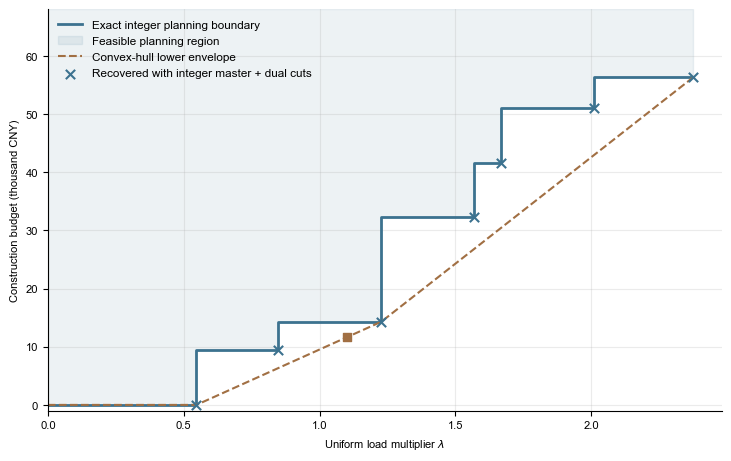

In [7]:
fig = plot_frontier(experiment, OUTPUT / "figures")
plt.show()

## 6. 固定预算的逐割收敛

主问题始终保留二元变量。下界来自实际可行设计的解析电气校核，上界来自含部分有效割的整数主问题；当两者相遇，证明本预算下的最大倍率。

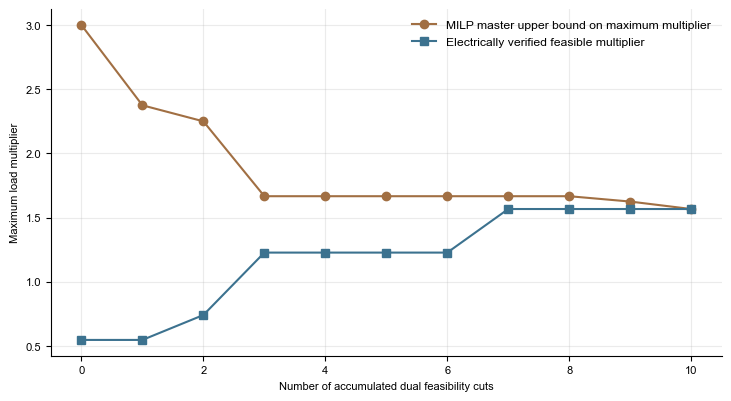

In [8]:
fig = plot_convergence(experiment, OUTPUT / "figures")
plt.show()

## 7. 切割如何逐步改变整个预算—能力关系

比较同一个整数主问题包含0条、冷启动收敛时的割以及全部累计割时的预算截面。这里的有限预算采样只是用于绘图；上面完整前沿的恢复不依赖这个采样网格。

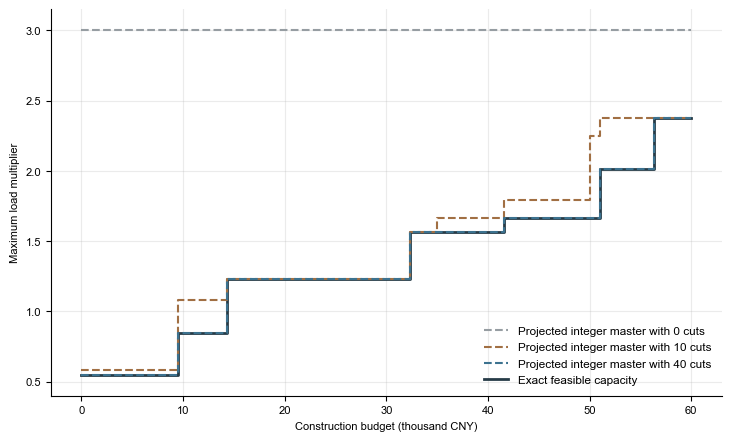

In [9]:
fig = plot_cut_snapshots(experiment, OUTPUT / "figures")
plt.show()

## 方法来源与适用限制

[SCIP Benders文档](https://www.scipopt.org/doc/html/BENDER.php)；[标准可行性割](https://www.scipopt.org/doc-7.0.2/html/benderscut__feas_8h.php)；[Gurobi关于MIP对偶值的说明](https://support.gurobi.com/hc/en-us/articles/360034305272-How-do-I-retrieve-the-dual-Pi-values-for-a-MIP-problem)；[Gurobi Python 建模接口](https://docs.gurobi.com/projects/optimizer/en/current/reference/python/model.html)；[Gurobi 线性约束 Pi 属性](https://docs.gurobi.com/projects/optimizer/en/current/reference/attributes/constraintlinear.html#pi)。

本实验不主张一种全新的Benders算法，也不比较大规模求解速度。目标是先验证正确的域定义、预算与目标函数的角色、整数变量保留的必要性，以及切割证书是否真的有效。
